<a href="https://colab.research.google.com/github/Ronaa-MX/Stochatic/blob/processes/SympyNetworkXTutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tutorial de las librerías Sympy y Networkx

Se enseña a utilizar la librería **Sympy** y **Networkx**, para cuestiones de procesos estocásticos.

Se presentan las formas de realizar con **Sympy**:

* Presentar matrices
* Multiplicación de matrices
* Potencia de una matriz a la n
* Multiplicación de un vector con una matriz
* Valores y vectores propios de una matriz

Con la librería **Networkx** veremos:
* La realización de un diagrama de transición de una cadena de markov a tiempo discreto *(CMTD)*

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Esta función permite que las matrices se impriman con un formato más legible (como en LaTeX)
sp.init_printing(use_unicode=True)

# Definimos algunos símbolos que podríamos usar más adelante (aunque en este caso usaremos números)
# p, q = sp.symbols('p q')

In [2]:
# Creación de la matriz de transición P.
# Se define como una lista de listas, donde cada sublista es una fila.
P = sp.Matrix([
    [0.0009, 0.0582, 0.9409],
    [0.0006, 0.0488, 0.9506],
    [0.0004, 0.0392, 0.9604]
])

print("Matriz de transición P (de {0,1,2} a {0,1,2}):")
sp.pprint(P)

Matriz de transición P (de {0,1,2} a {0,1,2}):
⎡0.0009  0.0582  0.9409⎤
⎢                      ⎥
⎢0.0006  0.0488  0.9506⎥
⎢                      ⎥
⎣0.0004  0.0392  0.9604⎦


In [3]:
print("\n--- Acceso a elementos ---")
# Acceder al elemento de la fila 1, columna 2 (es decir, P(1,2) = 0.9506)
elemento_12 = P[1, 2]
print(f"Probabilidad de ir del estado 1 al 2: {elemento_12}")

# Obtener la primera fila (estado 0)
fila_0 = P.row(0)
print(f"\nFila del estado 0 (desde donde sale): {fila_0}")

# Obtener la tercera columna (llegar al estado 2)
columna_2 = P.col(2)
print(f"Columna del estado 2 (hacia donde llega): {columna_2}")


--- Acceso a elementos ---
Probabilidad de ir del estado 1 al 2: 0.950600000000000

Fila del estado 0 (desde donde sale): Matrix([[0.000900000000000000, 0.0582000000000000, 0.940900000000000]])
Columna del estado 2 (hacia donde llega): Matrix([[0.940900000000000], [0.950600000000000], [0.960400000000000]])


In [4]:
print("\n--- Operaciones Básicas ---")
# Creemos una matriz identidad 3x3 y una matriz de unos para probar
I = sp.eye(3)
unos = sp.ones(3,3)

# Suma de matrices
suma = P + I  # A la matriz de transición le sumamos la identidad
print("P + I:\n", suma)

# Multiplicación de matrices (producto matricial)
producto = P * P  # Esto es P^2, las probabilidades de transición en dos pasos
print("\nP^2 (probabilidades en 2 pasos):")
sp.pprint(producto)  # Usamos pprint para una impresión más legible en consola

# Potencia de una matriz (otra forma de hacer P^2)
potencia = P**2
print("\nP elevado a la 2 (confirmación):")
sp.pprint(potencia)

# Multiplicación de una matriz por un vector (columna)
# Ejemplo: Distribución inicial [1, 0, 0] (empieza con 0 máquinas funcionando)
vector_inicial = sp.Matrix([1, 0, 0])  # Es una columna por defecto
distribucion_manana = P * vector_inicial
print(f"\nDistribución de probabilidad mañana si hoy hay 0 máquinas: {distribucion_manana}")
# La suma de este vector debe ser 1.
print(f"Suma de probabilidades: {sum(distribucion_manana)}")


--- Operaciones Básicas ---
P + I:
 Matrix([[1.00090000000000, 0.0582000000000000, 0.940900000000000], [0.000600000000000000, 1.04880000000000, 0.950600000000000], [0.000400000000000000, 0.0392000000000000, 1.96040000000000]])

P^2 (probabilidades en 2 pasos):
⎡0.00041209  0.03977582  0.95981209⎤
⎢                                  ⎥
⎢0.00041006  0.03967988  0.95991006⎥
⎢                                  ⎥
⎣0.00040804  0.03958392  0.96000804⎦

P elevado a la 2 (confirmación):
⎡0.00041209  0.03977582  0.95981209⎤
⎢                                  ⎥
⎢0.00041006  0.03967988  0.95991006⎥
⎢                                  ⎥
⎣0.00040804  0.03958392  0.96000804⎦

Distribución de probabilidad mañana si hoy hay 0 máquinas: Matrix([[0.000900000000000000], [0.000600000000000000], [0.000400000000000000]])
Suma de probabilidades: 0.00190000000000000


In [6]:
print("\n--- Eigenvalores y Eigenvectores ---")
# Calcular eigenvalores (con su multiplicidad algebraica)
eigenvals = P.eigenvals()
print("Eigenvalores de P (y su multiplicidad):")
print(eigenvals)  # Deberías ver el 1 como uno de ellos

# Calcular eigenvectores derechos
print("\nEigenvectores derechos:")
for eigenvalor, multiplicidad, eigenvectores in P.eigenvects():
    print(f"\nλ = {eigenvalor} (multiplicidad {multiplicidad})")
    for vec in eigenvectores:
        sp.pprint(vec)

# Para la distribución estacionaria (eigenvector izquierdo de P)
print("\n--- Distribución estacionaria (eigenvector izquierdo para λ=1) ---")
for eigenvalor, multiplicidad, eigenvectores in P.T.eigenvects():
    if eigenvalor == 1:
        pi = eigenvectores[0]                # vector columna
        pi = pi / sum(pi)                     # normalizar
        print("\nπ (fila normalizada):")
        sp.pprint(pi.T)
        print("\nVerificación π * P =")
        sp.pprint(pi.T * P)


--- Eigenvalores y Eigenvectores ---
Eigenvalores de P (y su multiplicidad):
{0.000100000000000000: 1, 0.0100000000000000: 1, 1.00000000000000: 1}

Eigenvectores derechos:

λ = 0.000100000000000000 (multiplicidad 1)
⎡ 0.999787415001993  ⎤
⎢                    ⎥
⎢-0.0206141735051957 ⎥
⎢                    ⎥
⎣0.000425034505261767⎦

λ = 0.0100000000000000 (multiplicidad 1)
⎡ 1.01042344550614  ⎤
⎢                   ⎥
⎢ 0.494794986201461 ⎥
⎢                   ⎥
⎣-0.0208334731032194⎦

λ = 1.00000000000000 (multiplicidad 1)
⎡-0.495741861584465⎤
⎢                  ⎥
⎢-0.495741861584465⎥
⎢                  ⎥
⎣-0.495741861584465⎦

--- Distribución estacionaria (eigenvector izquierdo para λ=1) ---


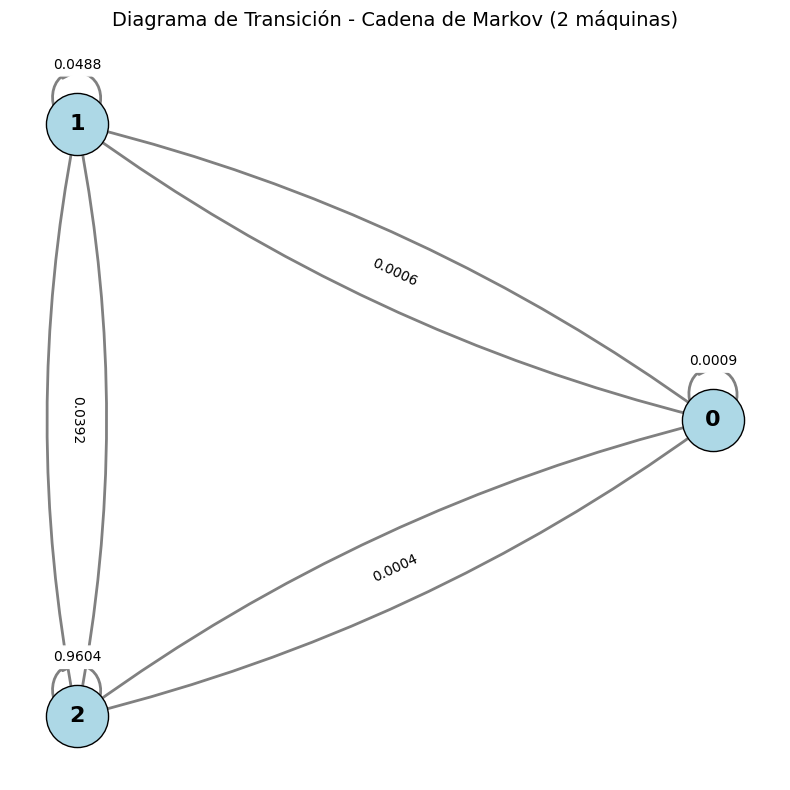

In [9]:
# 1. Crear el grafo dirigido
G = nx.DiGraph()
G.add_nodes_from([0, 1, 2])

# Añadir aristas con atributo 'prob'
G.add_edge(0, 0, prob=0.0009)
G.add_edge(0, 1, prob=0.0582)
G.add_edge(0, 2, prob=0.9409)

G.add_edge(1, 0, prob=0.0006)
G.add_edge(1, 1, prob=0.0488)
G.add_edge(1, 2, prob=0.9506)

G.add_edge(2, 0, prob=0.0004)
G.add_edge(2, 1, prob=0.0392)
G.add_edge(2, 2, prob=0.9604)

# 2. Elegir un layout que separe bien los nodos (circular)
pos = nx.circular_layout(G)  # los nodos se colocan en un círculo

plt.figure(figsize=(8, 8))

# 3. Dibujar nodos
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue', edgecolors='black')

# 4. Dibujar etiquetas de los nodos
nx.draw_networkx_labels(G, pos, font_size=16, font_weight='bold')

# 5. Dibujar aristas (incluyendo bucles)
#    Para los bucles, usamos un radio mayor (rad=0.4) para que sean más visibles
#    Para las aristas normales, podemos usar rad negativo para que no se superpongan
for (u, v, d) in G.edges(data=True):
    if u == v:
        # Bucle: arco pronunciado
        nx.draw_networkx_edges(
            G, pos,
            edgelist=[(u, v)],
            connectionstyle=f'arc3,rad=0.4',  # radio grande para el bucle
            arrows=True,
            arrowstyle='->',
            arrowsize=20,
            edge_color='gray',
            width=2
        )
    else:
        # Arista normal: ligeramente curvada para separar las bidireccionales si las hubiera
        nx.draw_networkx_edges(
            G, pos,
            edgelist=[(u, v)],
            connectionstyle=f'arc3,rad=0.1',  # curva suave
            arrows=True,
            arrowstyle='->',
            arrowsize=20,
            edge_color='gray',
            width=2
        )

# 6. Dibujar etiquetas de las aristas (probabilidades)
#    Se colocarán automáticamente en el centro de cada arco
edge_labels = {(u, v): f"{d['prob']:.4f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

# 7. Ajustes finales
plt.axis('off')
plt.title('Diagrama de Transición - Cadena de Markov (2 máquinas)', fontsize=14)
plt.tight_layout()
plt.show()